
# Gaia DR4 Epoch RV Error Model

This notebook makes the Gaia DR4 epoch RV error model for FGK stars.


In [ ]:

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('~/Desktop/Caltech/Projects/gaia_dr4_gaiamock_pipeline/results/rv_error_model_notebook_demo')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'font.family': 'serif',
    'axes.linewidth': 1.1,
})

print(f'Output directory: {OUTPUT_DIR}')


Output directory: /Users/bijan1339/Desktop/Caltech/Projects/gaia_dr4_gaiamock_pipeline/results/rv_error_model_notebook_demo


## Digitized Points from Anthony Brown's presentation
### see [https://zenodo.org/records/19452291](https://zenodo.org/records/19452291), slide 6

In [2]:
# ideally update with real data points

_GRVS_LINEAR = np.array([
    7.997242559665304, 8.127602928591804, 8.370043738708757, 8.655605210611391,
    8.854426167157936, 9.157269183227157, 9.373704478463441, 9.633070267186461,
    9.849386707235904, 10.100194922506418, 10.333721593610345, 10.55852429400019,
    10.835195397927166, 11.051416753827137, 11.379956261291243, 11.604687648568984,
    11.794879718550918, 11.985000475420748, 12.14921080155938, 12.373894646762384,
    12.555315203955502, 12.754088618427307, 12.987353808120186, 13.212013882285824,
    13.419368641247505, 13.566273652182183, 13.747622896263193, 13.95502519729961,
    14.196990586669202, 14.309284967195968, 14.464795093657887, 14.602976133878482,
    14.818936008367405, 15.000332794523153, 15.086716744318721, 15.294166587429876,
    15.484239802224968, 15.579323951697253, 15.821051630693164,
], dtype=float)

_ERR_LINEAR = np.array([
    0.4338730126091869, 0.3202539577230467, 0.2931115736038596, 0.2894266124716749,
    0.3202539577230467, 0.3202539577230467, 0.3006228432773891, 0.33687790490147,
    0.33687790490147, 0.35887652827032673, 0.3775053205324392, 0.4124626382901348,
    0.46220555937295427, 0.4861980210406236, 0.5587953033774357, 0.6341584770237424,
    0.6928820980810259, 0.7863291860548977, 0.8700825116137804, 1.0127319360880993,
    1.1787686347935855, 1.3377458931488975, 1.6173023172161307, 1.9064252445133645,
    2.2472342828110485, 2.486591218599788, 3.006228432773891, 3.4551072945922163,
    4.072772108711834, 4.506570337745471, 5.114358987471126, 5.878016072274909,
    7.106378769697888, 8.376776400682916, 9.037409390018174, 10.127319360880998,
    11.787686347935873, 12.399569106847382, 16.587472649501038,
], dtype=float)

_GRVS_NONE = np.array([
    8.014595416943996, 8.127602928591804, 8.361414852144149, 8.620970809166112,
    8.871731482361891, 9.165945611866501, 9.373680707426072, 9.650399353427783,
    9.953147285347534, 10.169321099172768, 10.523937434629648, 10.835171626889798,
    11.068698297993725, 11.371279832651897, 11.760316630217744, 12.062755538651707,
    12.512123229057718, 12.797328135399828, 13.004659123324142, 13.246576970618998,
    13.479865931349245, 13.652681373015119, 13.790719787011506, 13.972306741466197,
    14.12788818104022, 14.352476942093753, 14.499239326804222, 14.654654369116667,
    14.801464295901873, 14.87051915945612, 14.97387562993249, 15.103332699439003,
    15.215365598554722, 15.32737472663307, 15.585076542740325, 15.730959399068176,
    15.842421793287059,
], dtype=float)

_ERR_NONE = np.array([
    0.4230323952886754, 0.3202539577230467, 0.2894266124716749, 0.2931115736038596,
    0.3202539577230467, 0.3162277660168376, 0.3044503541046195, 0.3326427190621982,
    0.3499097499844492, 0.3775053205324392, 0.40727721087118274, 0.46809033101445485,
    0.49238826317067363, 0.5659098494663672, 0.6755699596090824, 0.8376776400682916,
    1.1348672281080412, 1.354777988362588, 1.6173023172161307, 1.9552792489728295,
    2.3341666954527107, 2.6489692876105244, 3.2846077743643005, 3.4990974998444937,
    3.8231169414637596, 4.680903310144551, 5.587953033774354, 6.670767806717144,
    7.764435563198173, 8.483428982440717, 10.926008611173774, 13.043213867190047,
    16.587472649501038, 21.363397911526565, 58.04118407660808, 110.65117854509276,
    190.64252445133647,
], dtype=float)


## Implemented Function

In [7]:
pwd

'/Users/bijan1339/Desktop/Caltech/Projects/gaia_dr4_gaiamock_pipeline/notebooks'

In [3]:

def _curve_data(filter_mode: str) -> tuple[np.ndarray, np.ndarray]:
    if filter_mode == 'linear':
        return _GRVS_LINEAR, _ERR_LINEAR
    if filter_mode == 'none':
        return _GRVS_NONE, _ERR_NONE
    raise ValueError(f"Unknown filter_mode '{filter_mode}'. Use 'linear' or 'none'.")


def get_realistic_epoch_rv_errors(
    grvs_mag: float | np.ndarray,
    filter_mode: str = 'linear',
    faint_mode: str = 'deweight',
    no_good_value: float = 1.0e6,
    deweight_from: float = 16.0,
    ) -> float | np.ndarray:
    """Approximate Gaia epoch-RV precision from the digitized G_RVS precision plot.

    Parameters
    ----------
    grvs_mag
        Gaia RVS magnitude(s).
    filter_mode
        Which digitized curve to use. The default is the blue ``linear`` filter curve.
    faint_mode
        Behavior beyond the faintest digitized point. ``'extrapolate'`` extends the
        final log-linear trend to larger errors at fainter magnitudes. ``'deweight'``
        extrapolates up to ``deweight_from`` and then returns ``no_good_value`` so the
        RV term becomes effectively irrelevant in downstream fits. ``'nan'`` returns
        ``no_good_value`` for all fainter magnitudes.
    no_good_value
        Value returned when the source should contribute effectively no RV information.
    deweight_from
        Magnitude at or above which the ``'deweight'`` mode returns ``no_good_value``.

    Returns
    -------
    float or ndarray
        Approximate epoch-RV uncertainty in km/s.
    """

    grvs_nodes, err_nodes = _curve_data(filter_mode)
    scalar_input = np.ndim(grvs_mag) == 0
    x = np.atleast_1d(np.asarray(grvs_mag, dtype=float))
    y = np.full_like(x, no_good_value, dtype=float)

    bright = x <= grvs_nodes[0]
    y[bright] = err_nodes[0]

    in_range = (x > grvs_nodes[0]) & (x <= grvs_nodes[-1])
    if np.any(in_range):
        y[in_range] = 10 ** np.interp(x[in_range], grvs_nodes, np.log10(err_nodes))

    x1, x2 = grvs_nodes[-2], grvs_nodes[-1]
    y1, y2 = np.log10(err_nodes[-2]), np.log10(err_nodes[-1])
    slope = (y2 - y1) / (x2 - x1)

    faint_extrap = x > grvs_nodes[-1]
    if faint_mode == 'extrapolate':
        if np.any(faint_extrap):
            y[faint_extrap] = 10 ** (y2 + slope * (x[faint_extrap] - x2))
    elif faint_mode == 'deweight':
        faint_mid = (x > grvs_nodes[-1]) & (x < deweight_from)
        very_faint = x >= deweight_from
        if np.any(faint_mid):
            y[faint_mid] = 10 ** (y2 + slope * (x[faint_mid] - x2))
        if np.any(very_faint):
            y[very_faint] = no_good_value
    elif faint_mode == 'nan':
        if np.any(faint_extrap):
            y[faint_extrap] = no_good_value
    else:
        raise ValueError(
            f"Unknown faint_mode '{faint_mode}'. Use 'extrapolate', 'deweight', or 'nan'."
        )

    if scalar_input:
        return float(y[0])
    return y


## Sanity Checks

In [4]:

# The implementation should reproduce the supplied node values exactly when we use
# the extrapolating visualization mode.
linear_eval = get_realistic_epoch_rv_errors(_GRVS_LINEAR, filter_mode='linear', faint_mode='extrapolate')
none_eval = get_realistic_epoch_rv_errors(_GRVS_NONE, filter_mode='none', faint_mode='extrapolate')

assert np.allclose(linear_eval, _ERR_LINEAR)
assert np.allclose(none_eval, _ERR_NONE)

print('Node-level checks passed.')
print(f"Example: linear G_RVS=14.8 -> {get_realistic_epoch_rv_errors(14.8, filter_mode='linear', faint_mode='extrapolate'):.3f} km/s")
print(f"Example: none   G_RVS=15.5 -> {get_realistic_epoch_rv_errors(15.5, filter_mode='none', faint_mode='extrapolate'):.3f} km/s")
print(f"Pipeline-style deweight at G_RVS=16.0 -> {get_realistic_epoch_rv_errors(16.0, filter_mode='linear', faint_mode='deweight'):.1f} km/s")


Node-level checks passed.
Example: linear G_RVS=14.8 -> 6.989 km/s
Example: none   G_RVS=15.5 -> 41.729 km/s
Pipeline-style deweight at G_RVS=16.0 -> 1000000.0 km/s


## Comparison Figure

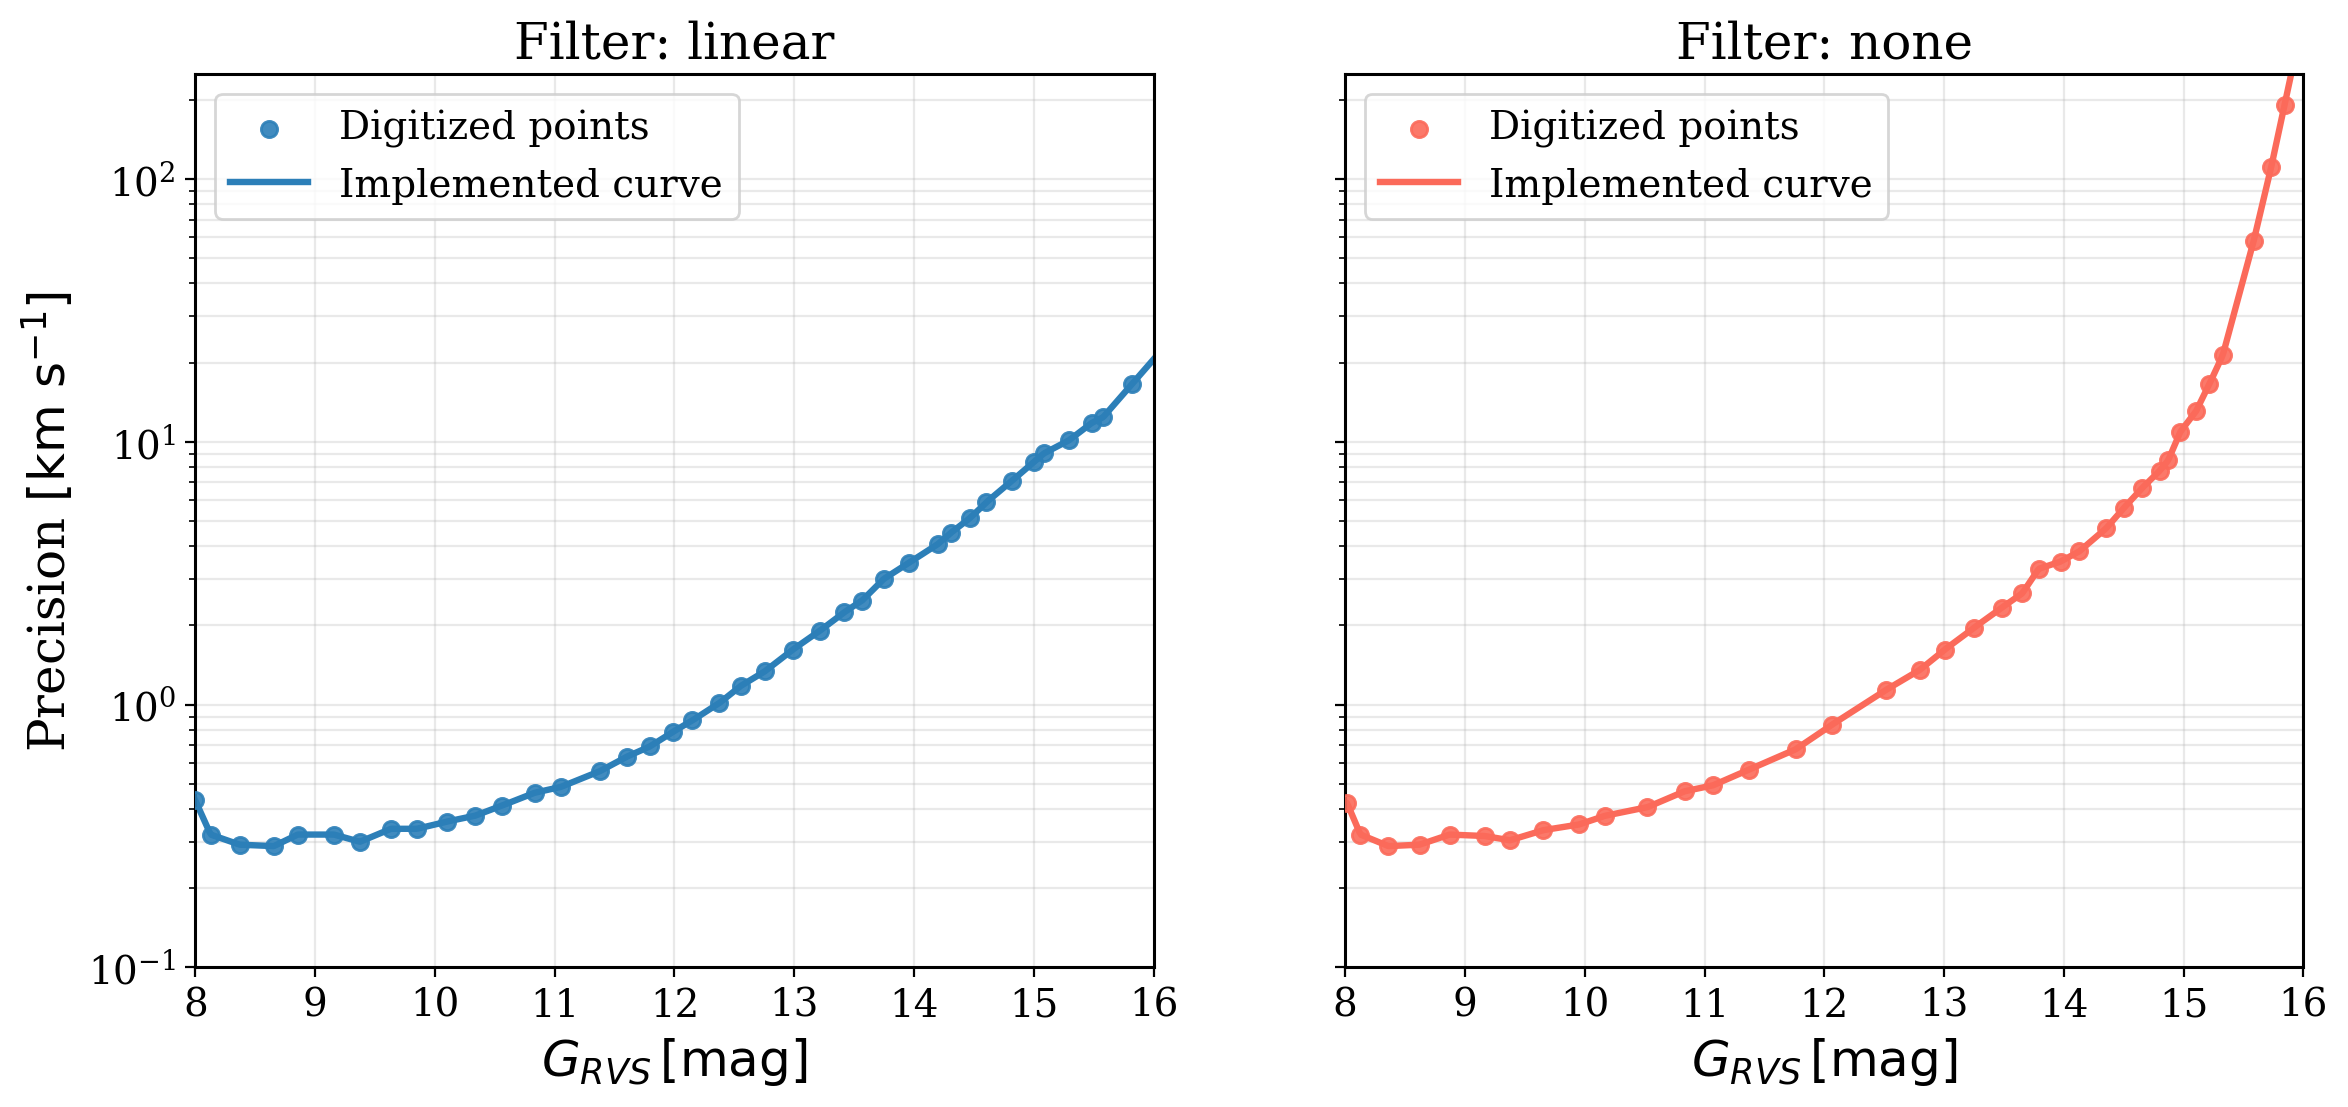

In [6]:

def make_rv_error_model_comparison_figure(output_dir: Path) -> tuple[Path, Path]:
    x_plot = np.linspace(8.0, 16.0, 600)

    fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.8), sharey=True)
    configs = [
        ('linear', '#2C7FB8', axes[0], _GRVS_LINEAR, _ERR_LINEAR),
        ('none', '#FB6A5A', axes[1], _GRVS_NONE, _ERR_NONE),
    ]

    for filter_mode, color, ax, x_nodes, y_nodes in configs:
        y_plot = get_realistic_epoch_rv_errors(x_plot, filter_mode=filter_mode, faint_mode='extrapolate')
        ax.scatter(x_nodes, y_nodes, s=34, color=color, alpha=0.9, label='Digitized points', zorder=3)
        ax.plot(x_plot, y_plot, color=color, lw=2.3, label='Implemented curve', zorder=2)
        ax.set_title(f'Filter: {filter_mode}')
        ax.set_xlim(8.0, 16.0)
        ax.set_yscale('log')
        ax.grid(True, which='both', alpha=0.28)
        ax.legend(loc='upper left', frameon=True)
        ax.set_xlabel(r'$G_{RVS}\,[\mathrm{mag}]$')

    axes[0].set_ylabel(r'Precision $[\mathrm{km\ s^{-1}}]$')
    axes[0].set_ylim(1e-1, 2.5e2)

    png_path = output_dir / 'rv_error_model_comparison_notebook.png'
    pdf_path = output_dir / 'rv_error_model_comparison_notebook.pdf'
    fig.savefig(png_path)
    fig.savefig(pdf_path)
    plt.show()
    plt.close(fig)
    return png_path, pdf_path


png_path, pdf_path = make_rv_error_model_comparison_figure(OUTPUT_DIR)



## Notes

- The project default is `filter_mode='linear'`.
- For the figure in this notebook, we use `faint_mode='extrapolate'` so the displayed curve remains a smooth visual continuation of the digitized trend up to `G_RVS = 16`. The RV errors blow up fainter than this
